# Active Product Sales Analysis

## Importing libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df= pd.read_csv('Active Product Sales Analysis Data.csv')
df

,Name,Email,Product,Transaction Date
0,PERSON_1,PERSON_1@gmail.com,PRODUCT_75,01/03/2021 00:47:26
1,PERSON_2,PERSON_2@tataprojects.com,PRODUCT_75,01/03/2021 02:04:07
2,PERSON_3,PERSON_3@gmail.com,PRODUCT_63,01/03/2021 09:10:43
3,PERSON_4,PERSON_4@gmail.com,PRODUCT_63,01/03/2021 09:49:48
4,PERSON_5,PERSON_5@gmail.com,"PRODUCT_34,PRODUCT_86,PRODUCT_57,PRODUCT_89",01/03/2021 10:56:46
...,...,...,...,...
576,PERSON_522,PERSON_522@gmail.com,"PRODUCT_48,PRODUCT_80,PRODUCT_71,PRODUCT_68,PR...",07/03/2021 23:53:03
577,PERSON_523,PERSON_523@gmail.com,PRODUCT_8,07/03/2021 23:55:01
578,PERSON_523,PERSON_523@gmail.com,"PRODUCT_36,PRODUCT_14,PRODUCT_64,PRODUCT_28,PR...",07/03/2021 23:58:24
579,PERSON_524,PERSON_524@gmail.com,"PRODUCT_75,PRODUCT_71,PRODUCT_86,PRODUCT_63,PR...",07/03/2021 23:59:26


In [58]:
df.head()

,Name,Email,Product,Transaction Date
0,PERSON_1,PERSON_1@gmail.com,PRODUCT_75,01/03/2021 00:47:26
1,PERSON_2,PERSON_2@tataprojects.com,PRODUCT_75,01/03/2021 02:04:07
2,PERSON_3,PERSON_3@gmail.com,PRODUCT_63,01/03/2021 09:10:43
3,PERSON_4,PERSON_4@gmail.com,PRODUCT_63,01/03/2021 09:49:48
4,PERSON_5,PERSON_5@gmail.com,"PRODUCT_34,PRODUCT_86,PRODUCT_57,PRODUCT_89",01/03/2021 10:56:46


## Extracting the Hour from Datetime column 

In [59]:
df['Transaction_time']= pd.to_datetime(df['Transaction Date'])
df['Transaction_time']

0     2021-01-03 00:47:26
1     2021-01-03 02:04:07
2     2021-01-03 09:10:43
3     2021-01-03 09:49:48
4     2021-01-03 10:56:46
              ...        
576   2021-07-03 23:53:03
577   2021-07-03 23:55:01
578   2021-07-03 23:58:24
579   2021-07-03 23:59:26
580   2021-07-03 23:59:19
Name: Transaction_time, Length: 581, dtype: datetime64[ns]

In [60]:
df['hour']= pd.to_datetime(df['Transaction_time']).dt.hour
df['hour']

0       0
1       2
2       9
3       9
4      10
       ..
576    23
577    23
578    23
579    23
580    23
Name: hour, Length: 581, dtype: int32

## Cumulative purchases per hour

In [71]:
temp = df['hour'].value_counts()
temp

hour
23    51
12    51
22    45
19    42
21    41
15    41
20    39
11    37
13    33
18    33
16    29
14    28
17    27
10    24
0     17
9     14
8     10
7      6
1      4
2      3
5      3
6      2
3      1
Name: count, dtype: int64

In [61]:
timemost = df['hour'].value_counts().index.tolist()[:24]
print(timemost,)

[23, 12, 22, 19, 21, 15, 20, 11, 13, 18, 16, 14, 17, 10, 0, 9, 8, 7, 1, 2, 5, 6, 3]


In [69]:
cumulative_purchases = df['hour'].value_counts().values.tolist()[:24]
print(cumulative_purchases,)

[51, 51, 45, 42, 41, 41, 39, 37, 33, 33, 29, 28, 27, 24, 17, 14, 10, 6, 4, 3, 3, 2, 1]


### Sorting the data 

In [80]:
timemost_temp = df['hour'].value_counts()
timemost = []

for i in range(0,23):
    timemost.append(i)

cumulative_purchases = timemost_temp.sort_index()
cumulative_purchases.tolist()
cumulative_purchases = pd.DataFrame(cumulative_purchases)
cumulative_purchases

,count
hour,
0,17
1,4
2,3
3,1
5,3
6,2
7,6
8,10
9,14


# Data Visualization

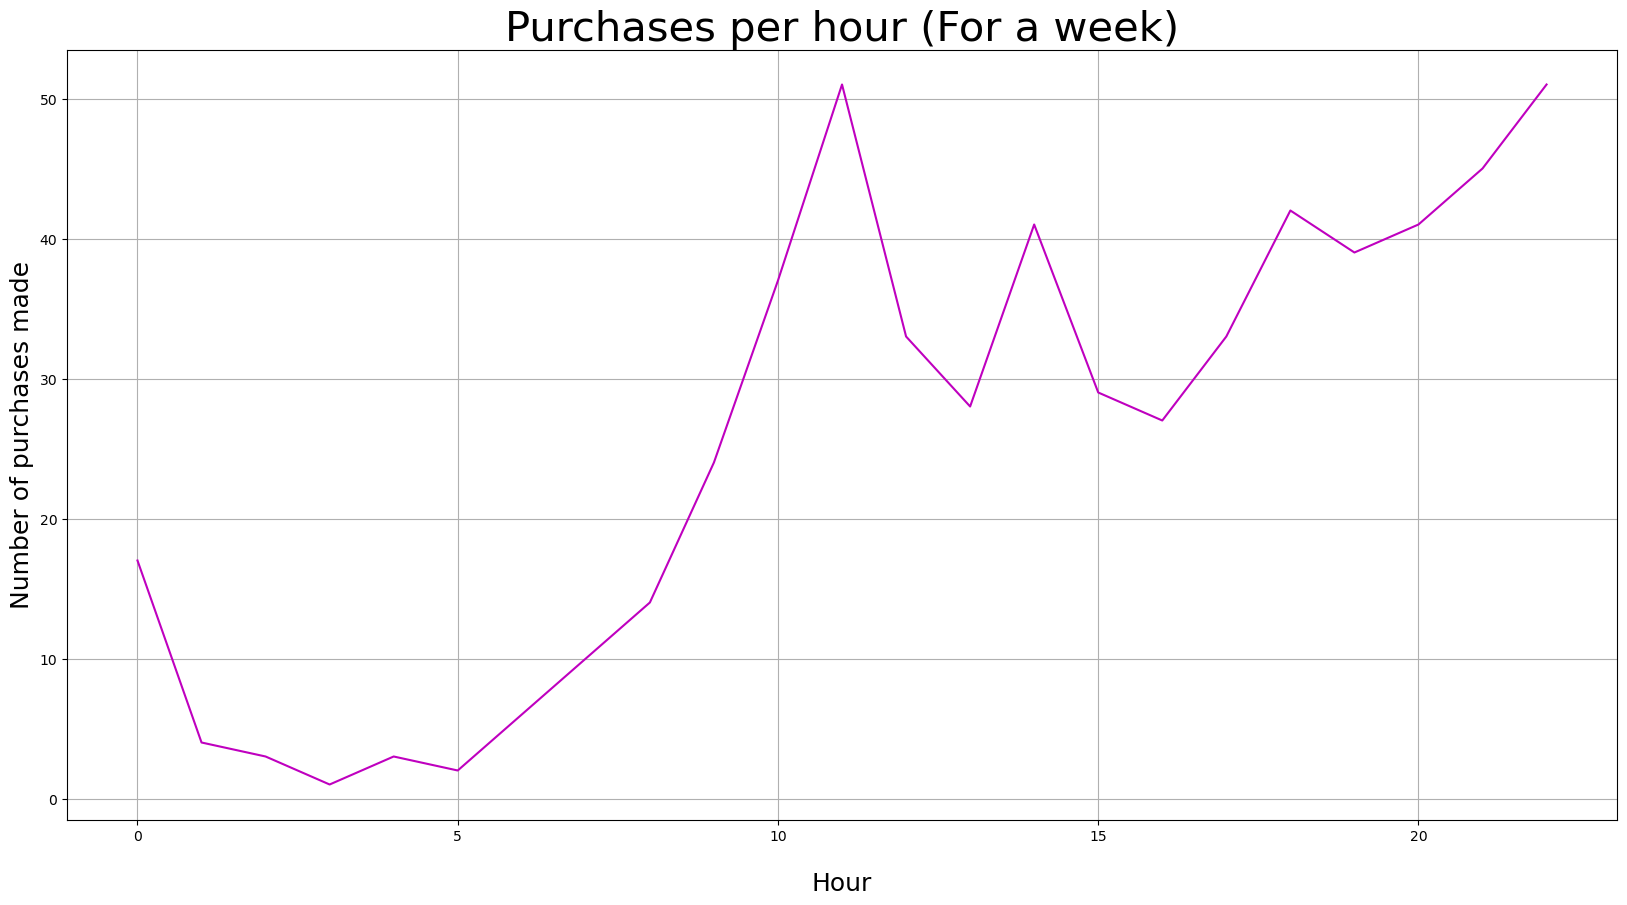

In [93]:
plt.figure(figsize=(20, 10))

plt.title('Purchases per hour (For a week)', fontsize= 30)

plt.ylabel("Number of purchases made", fontsize=18)
plt.xlabel("Hour", fontsize=18, labelpad=20)
plt.plot(timemost, cumulative_purchases, color='m')
plt.grid()
plt.show()

# Analysis:

### After Analysing the following graph we can conclude that the sales per hour typically peaks after the 10th hour of the day or we can say that the sales peaks in the evening time of the day.